In [11]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset

from models.basemodel import CNNWithSizeMLP

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix
from engine.data_setup import setup_datasets
print("All libraries imported successfully!")

All libraries imported successfully!


In [12]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6337
Validation subset size: 1585
Dataset setup complete.


# Functions for extract features

In [22]:
import torch
import numpy as np

def extract_backbone_and_combined(model, loader, device, selected_classes=(4,6,8)):
    """
    Returns:
      X_backbone: [N, D] backbone features
      X_combined: [N, D+2] backbone features concatenated with size
      sizes_np:   [N, 2]  (major, minor)
      y_np:       [N]
    """
    model.eval()
    selected_classes = torch.tensor(selected_classes, device=device)

    feats_list, comb_list, sizes_list, y_list = [], [], [], []

    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            mask = torch.isin(labels, selected_classes)
            if mask.sum() == 0:
                continue

            imgs_m = imgs[mask]
            sizes_m = sizes[mask]
            labels_m = labels[mask]

            # backbone features
            f = model.backbone(imgs_m)                 # [b, D]
            x_comb = torch.cat([f, sizes_m], dim=1)    # [b, D+2]

            feats_list.append(f.cpu())
            comb_list.append(x_comb.cpu())
            sizes_list.append(sizes_m.cpu())
            y_list.append(labels_m.cpu())

    X_backbone = torch.cat(feats_list, dim=0).numpy()
    X_combined = torch.cat(comb_list, dim=0).numpy()
    sizes_np   = torch.cat(sizes_list, dim=0).numpy()
    y_np       = torch.cat(y_list, dim=0).numpy()

    return X_backbone, X_combined, sizes_np, y_np

## helper plot function

In [25]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_2d(X_2d, y, idx_to_class, title):
    plt.figure(figsize=(8,6))
    for cls in sorted(np.unique(y)):
        mask = (y == cls)
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.7, label=idx_to_class[int(cls)])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## scatter plot for size features

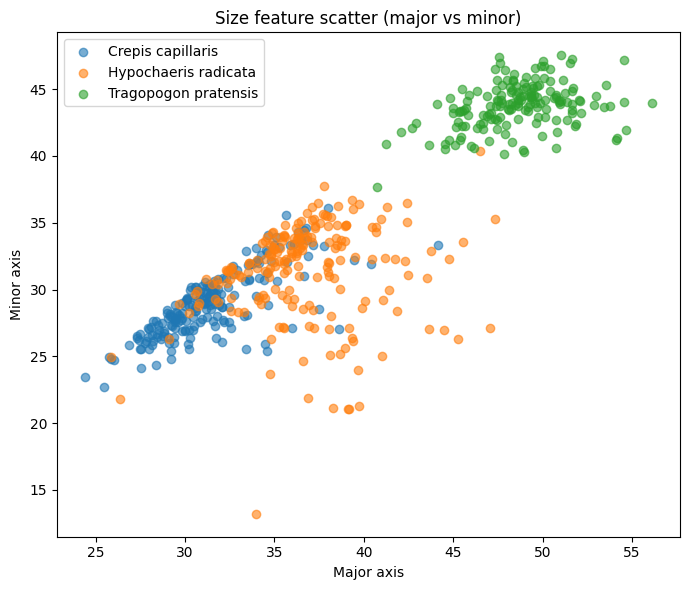

In [28]:
def plot_size_scatter(S, y, idx_to_class, classes=(4,6,8)):
    plt.figure(figsize=(7,6))
    for cls in classes:
        mask = (y == cls)
        plt.scatter(S[mask, 0], S[mask, 1], alpha=0.6, label=idx_to_class[cls])
    plt.xlabel("Major axis")
    plt.ylabel("Minor axis")
    plt.title("Size feature scatter (major vs minor)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_size_scatter(S, y, idx_to_class, classes=(4,6,8))

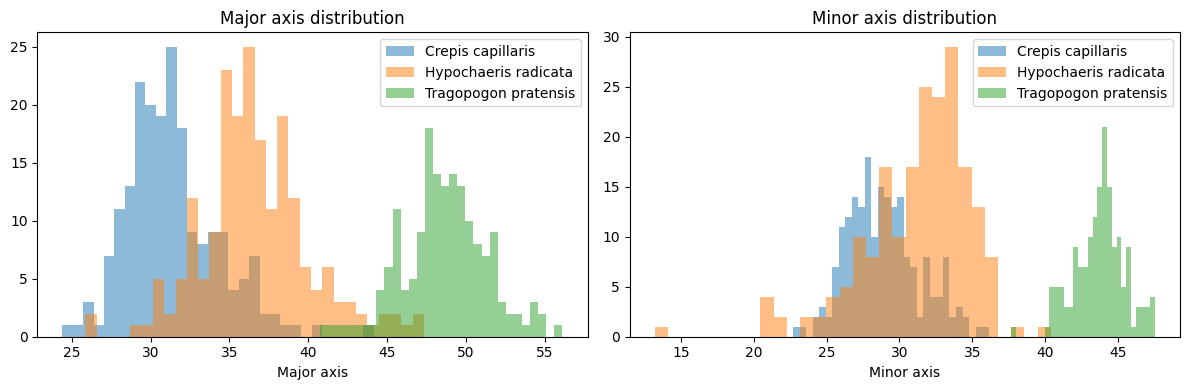

In [29]:
def plot_size_histograms(S, y, idx_to_class, classes=(4,6,8), bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    for cls in classes:
        mask = (y == cls)
        axes[0].hist(S[mask, 0], bins=bins, alpha=0.5, label=idx_to_class[cls])
        axes[1].hist(S[mask, 1], bins=bins, alpha=0.5, label=idx_to_class[cls])

    axes[0].set_title("Major axis distribution")
    axes[0].set_xlabel("Major axis")

    axes[1].set_title("Minor axis distribution")
    axes[1].set_xlabel("Minor axis")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_size_histograms(S, y, idx_to_class, classes=(4,6,8))

## Base model Erik's.
### Investigating PCA and t-SNE for class 4,6,8

In [13]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
base_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(base_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)



Using device: cuda


Test Accuracy: 0.7555
Test Recall per class:
Class 0 (Bellis perennis): 0.2042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.8197
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.9650
Class 6 (Hypochaeris radicata): 0.8150
Class 7 (Sonchus arvensis): 0.7665
Class 8 (Tragopogon pratensis): 0.9880
Class 9 (Tussilago farfara): 1.0000


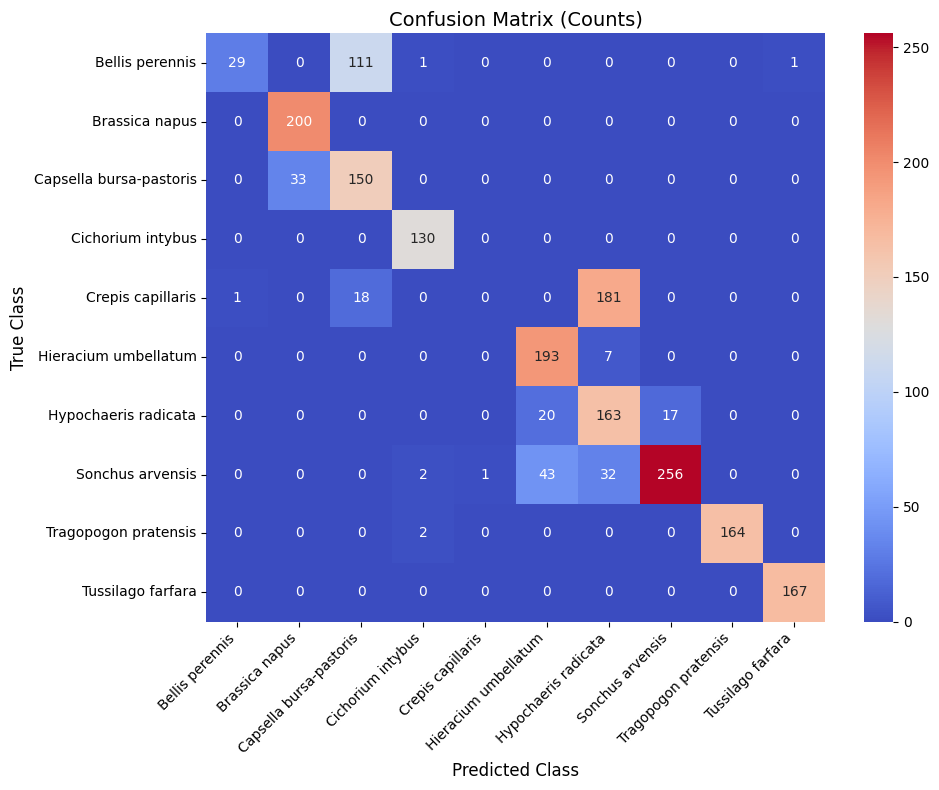

In [14]:
BATCHSIZE = 32

base_model.load_state_dict(torch.load("models/saved_models/base_model.pth"))

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(base_model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [24]:
Xb, Xc, S, y = extract_backbone_and_combined(base_model, test_loader, device, selected_classes=(4,6,8))
print(Xb.shape, Xc.shape, S.shape, y.shape)




(566, 512) (566, 514) (566, 2) (566,)


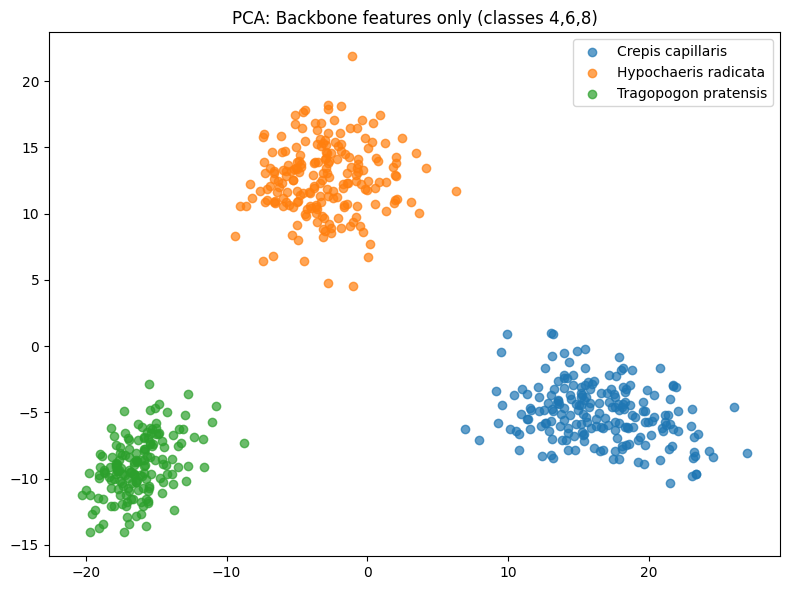

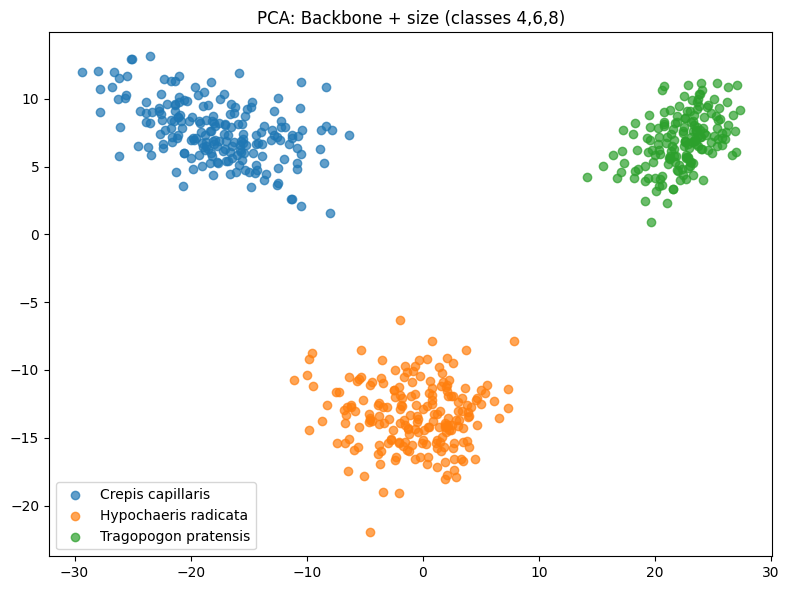

In [26]:
pca_b = PCA(n_components=2).fit_transform(Xb)
plot_2d(pca_b, y, idx_to_class, "PCA: Backbone features only (classes 4,6,8)")

pca_c = PCA(n_components=2).fit_transform(Xc)
plot_2d(pca_c, y, idx_to_class, "PCA: Backbone + size (classes 4,6,8)")

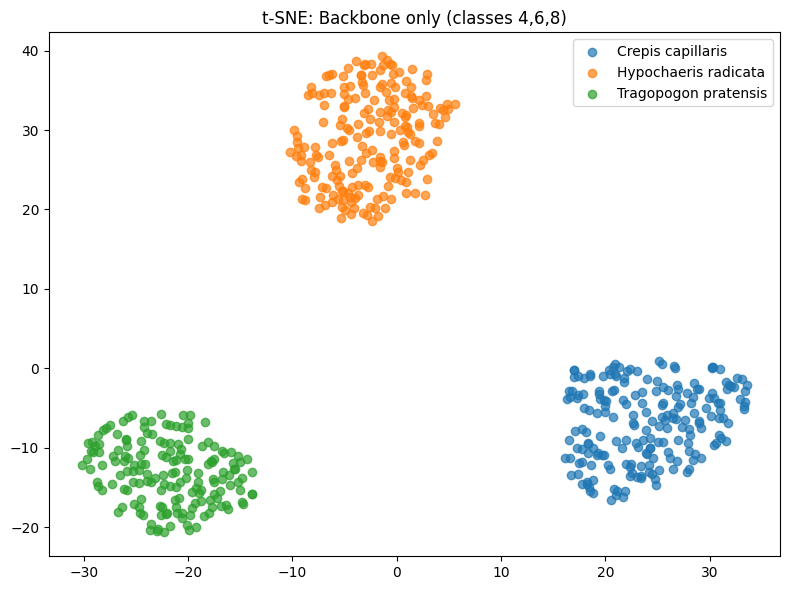

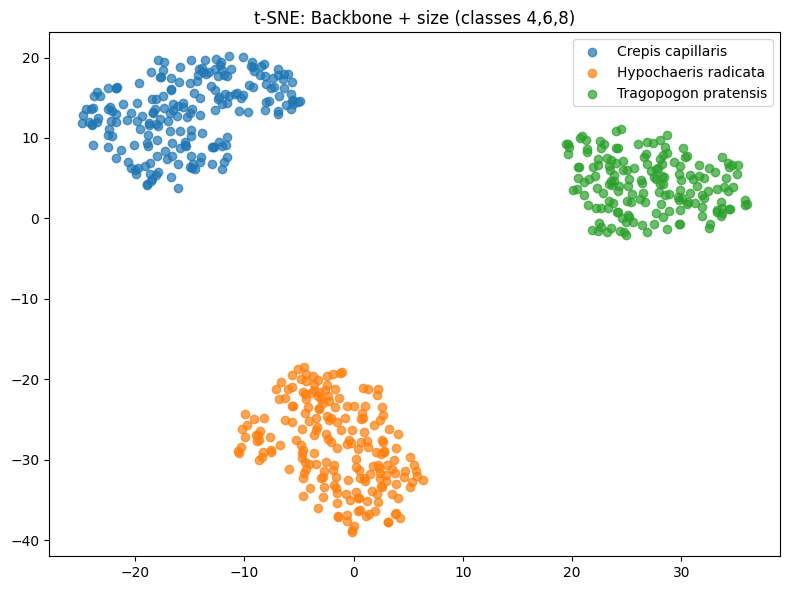

In [27]:
subset = min(1500, len(y))
Xb_sub, Xc_sub, y_sub = Xb[:subset], Xc[:subset], y[:subset]

tsne_b = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xb_sub)
plot_2d(tsne_b, y_sub, idx_to_class, "t-SNE: Backbone only (classes 4,6,8)")

tsne_c = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xc_sub)
plot_2d(tsne_c, y_sub, idx_to_class, "t-SNE: Backbone + size (classes 4,6,8)")

In [31]:
def eval_without_size(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            sizes_zero = torch.zeros_like(sizes).to(device) 

            logits = model(imgs, sizes_zero)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

acc_no_size = eval_without_size(base_model, test_loader, device)
print("Test accuracy with size set to 0:", acc_no_size)

Test accuracy with size set to 0: 0.6956295525494277


In [32]:
W = base_model.fc.weight.data  # shape [10, 514]

# Last two columns correspond to size
size_weights = W[:, -2:]
backbone_weights = W[:, :-2]

print("Mean abs backbone weight:", backbone_weights.abs().mean())
print("Mean abs size weight:", size_weights.abs().mean())

Mean abs backbone weight: tensor(0.0467, device='cuda:0')
Mean abs size weight: tensor(0.0461, device='cuda:0')


In [33]:
import numpy as np

print("Backbone features:")
print("  mean abs:", np.mean(np.abs(Xb)))
print("  std:", np.std(Xb))
print("  per-dim std (median):", np.median(np.std(Xb, axis=0)))

print("\nSize features:")
print("  mean abs:", np.mean(np.abs(S)))
print("  std:", np.std(S))
print("  per-dim std:", np.std(S, axis=0))

Backbone features:
  mean abs: 0.8292553
  std: 1.0143002
  per-dim std (median): 0.5893494

Size features:
  mean abs: 36.21054
  std: 7.5716667
  per-dim std: [7.643708 6.886668]


# FL

In [15]:
from os import access
from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(focal_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [17]:

def extract_selected_features(model, loader, device, selected_classes):
    """
    Extract backbone features only for selected classes.
    """
    model.eval()
    
    all_features = []
    all_labels = []

    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            # Extract backbone features
            features = model.backbone(imgs)  # [B, feature_dim]

            # Select only desired classes
            mask = torch.isin(labels, torch.tensor(selected_classes).to(device))

            if mask.sum() > 0:
                all_features.append(features[mask].cpu())
                all_labels.append(labels[mask].cpu())

    X = torch.cat(all_features).numpy()
    y = torch.cat(all_labels).numpy()

    return X, y

In [18]:
selected_classes = [4, 6, 8]

X, y = extract_selected_features(
    focal_model,
    test_loader,
    device,
    selected_classes
)

print("Feature shape:", X.shape)

Feature shape: (566, 512)


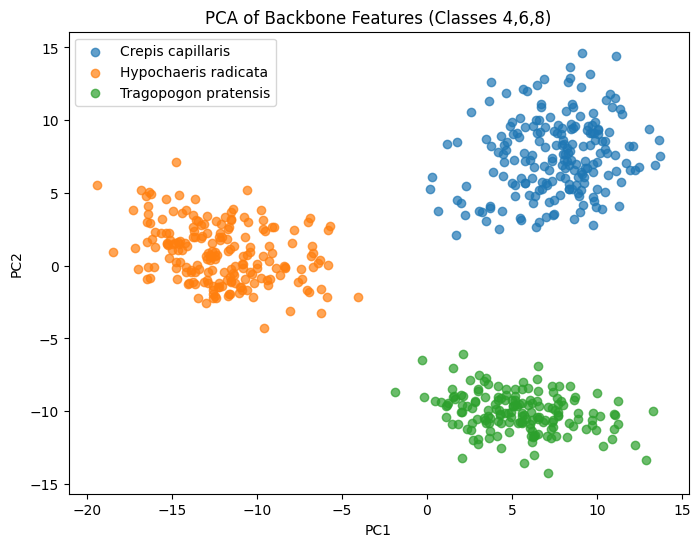

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for cls in selected_classes:
    mask = (y == cls)
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=idx_to_class[cls],
        alpha=0.7
    )

plt.title("PCA of Backbone Features (Classes 4,6,8)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [20]:
subset = 1500  # adjust if needed
X_sub = X[:subset]
y_sub = y[:subset]

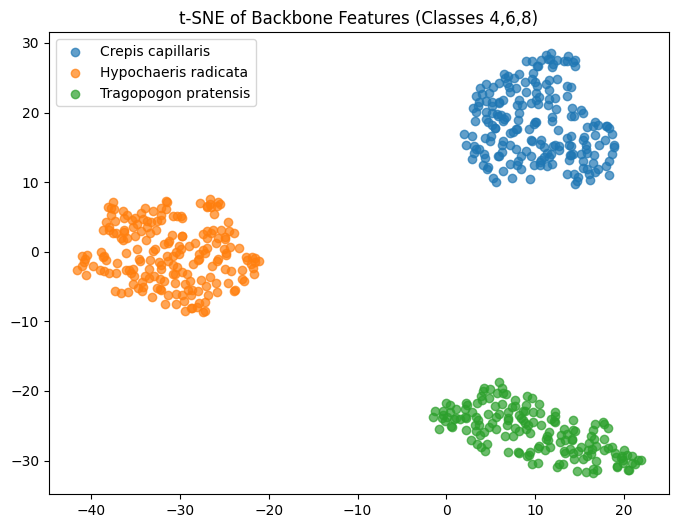

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca'
)

X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(8,6))

for cls in selected_classes:
    mask = (y_sub == cls)
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=idx_to_class[cls],
        alpha=0.7
    )

plt.title("t-SNE of Backbone Features (Classes 4,6,8)")
plt.legend()
plt.show()